In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Halal - Store\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#data cleaning 

In [4]:
df.drop("customerID", axis=1, inplace=True)

# Fix TotalCharges
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

C:\Users\Halal - Store\AppData\Local\Temp\ipykernel_10140\1408809172.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


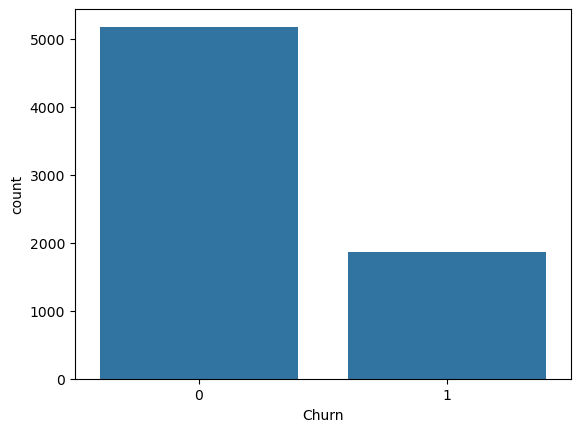

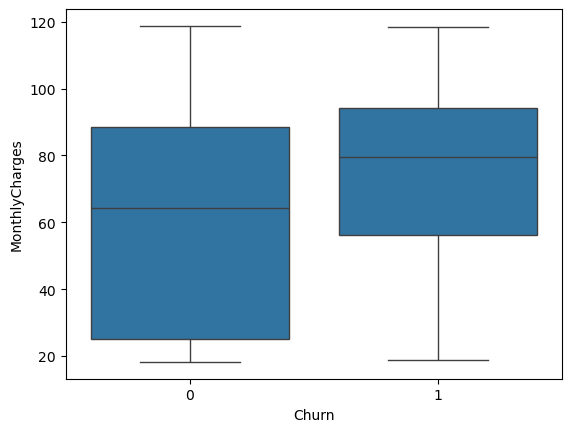

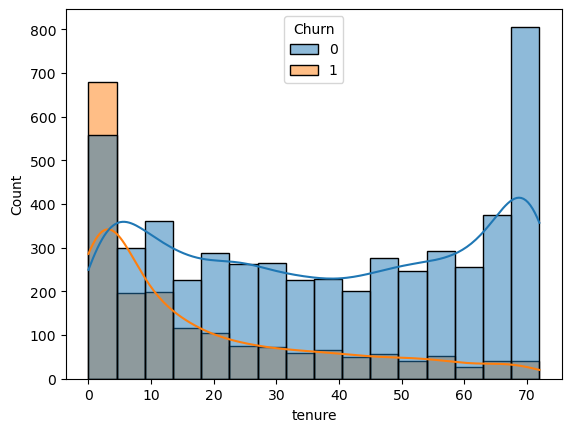

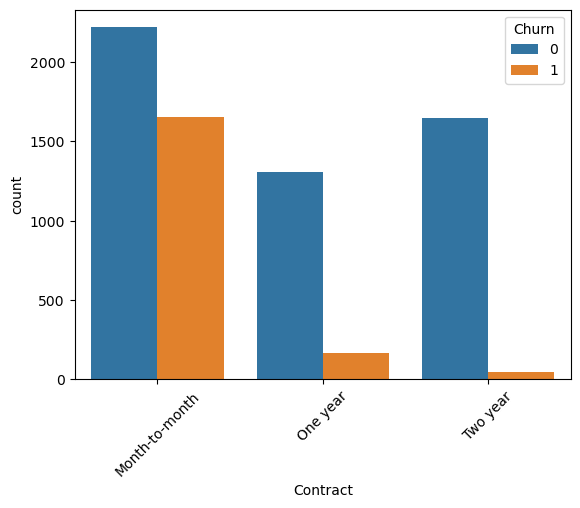

In [5]:
#EDA
sns.countplot(x="Churn", data=df)
plt.show()

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

sns.histplot(data=df, x="tenure", hue="Churn", kde=True)
plt.show()

sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.show()

In [6]:
#feature eng..
df["MonthlyRatio"] = df["TotalCharges"] / (df["tenure"] + 1)

In [7]:
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn']

In [9]:
#trian test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
#scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
#Train models

In [13]:
#logistic regression 
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [14]:
#random forest 
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

In [15]:
#Decision TRee
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)

In [16]:
#Evaluation 
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

Random Forest:
Accuracy: 0.7665010645848119
Precision: 0.5753424657534246
Recall: 0.450402144772118


In [17]:
import joblib

joblib.dump(rf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [18]:
#The Random Forest model was selected as the final model due to its strong performance in recall and accuracy.

#Recall was prioritized because the goal is to correctly identify customers who are likely to churn.

#The model was saved and deployed using Flask for real-time prediction.